## Análisis del Mercado Laboral de Analistas de Datos

## IMPORTACIÓN DE LIBRERÍAS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## CARGA DEL DATASET

In [2]:
df = pd.read_csv("../data/analisis_mercado.csv")
df.head()

,ID,Empresa,País,Nivel,Salario,Python,SQL,Excel,PowerBI,Tableau,R
0,1,VisionAnalytics,España,Mid,43819,No,Sí,Sí,Sí,Sí,No
1,2,VisionAnalytics,Argentina,Mid,44041,Sí,Sí,Sí,Sí,Sí,Sí
2,3,BusinessData,México,Junior,39654,Sí,Sí,No,No,Sí,No
3,4,InsightTech,Brasil,Junior,35514,Sí,Sí,Sí,Sí,Sí,No
4,5,MarketData,España,Mid,55403,Sí,Sí,Sí,No,No,No


## EXPLORACIÓN INICIAL

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ID       500 non-null    int64
 1   Empresa  500 non-null    str  
 2   País     500 non-null    str  
 3   Nivel    500 non-null    str  
 4   Salario  500 non-null    int64
 5   Python   500 non-null    str  
 6   SQL      500 non-null    str  
 7   Excel    500 non-null    str  
 8   PowerBI  500 non-null    str  
 9   Tableau  500 non-null    str  
 10  R        500 non-null    str  
dtypes: int64(2), str(9)
memory usage: 43.1 KB


In [4]:
df.describe()

,ID,Salario
count,500.000000,500.000000
mean,250.500000,53202.956000
std,144.481833,21734.035897
min,1.000000,30006.000000
25%,125.750000,36275.750000
50%,250.500000,45257.000000
75%,375.250000,61775.500000
max,500.000000,109994.000000


In [5]:
df.columns

Index(['ID', 'Empresa', 'País', 'Nivel', 'Salario', 'Python', 'SQL', 'Excel',
       'PowerBI', 'Tableau', 'R'],
      dtype='str')

## LIMPIEZA DE DATOS

In [6]:
# Valores faltantes
df.isnull().sum()

ID         0
Empresa    0
País       0
Nivel      0
Salario    0
Python     0
SQL        0
Excel      0
PowerBI    0
Tableau    0
R          0
dtype: int64

In [7]:
# Eliminar duplicados
df = df.drop_duplicates()

In [8]:
# Revisar valores únicos
df["Nivel"].unique()

<StringArray>
['Mid', 'Junior', 'Senior']
Length: 3, dtype: str

In [9]:
# Corregir formato
df["Nivel"] = df["Nivel"].str.capitalize()

In [10]:
# Verificar herramientas
tools = ["Python", "SQL", "Excel", "PowerBI", "Tableau", "R"]
for col in tools:
    print(col, df[col].unique())

Python <StringArray>
['No', 'Sí']
Length: 2, dtype: str
SQL <StringArray>
['Sí']
Length: 1, dtype: str
Excel <StringArray>
['Sí', 'No']
Length: 2, dtype: str
PowerBI <StringArray>
['Sí', 'No']
Length: 2, dtype: str
Tableau <StringArray>
['Sí', 'No']
Length: 2, dtype: str
R <StringArray>
['No', 'Sí']
Length: 2, dtype: str


## ANÁLISIS EXPLORATORIO (EDA)

In [11]:
#Distribución de niveles
df["Nivel"].value_counts()

Nivel
Junior    239
Mid       159
Senior    102
Name: count, dtype: int64

In [12]:
#Herrramientas mas solicitadas
df[tools].apply(lambda x: (x == "Sí").sum())

Python     301
SQL        500
Excel      406
PowerBI    288
Tableau    189
R          119
dtype: int64

In [13]:
#Herramientas por nivel
table = pd.crosstab(df["Nivel"], df["Python"])
print(table)

Python  No   Sí
Nivel          
Junior  90  149
Mid     68   91
Senior  41   61


In [14]:
#Salario Promedio
df.groupby("Nivel")["Salario"].mean()

Nivel
Junior    36035.414226
Mid       54981.402516
Senior    90656.578431
Name: Salario, dtype: float64

## VISUALIZACIONES


<function matplotlib.pyplot.show(close=None, block=None)>

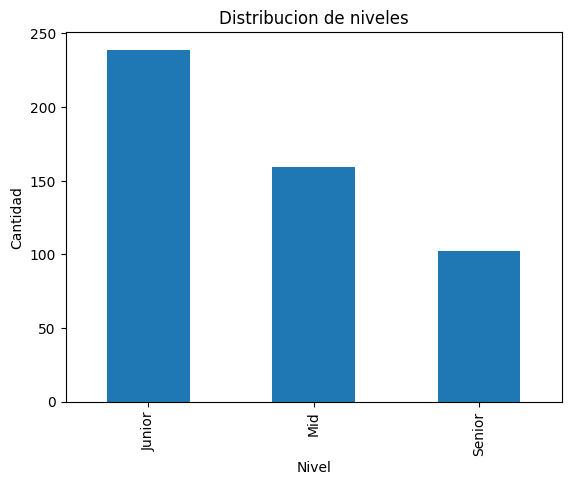

In [15]:
#Distribución de niveles
df["Nivel"].value_counts().plot(kind="bar")
plt.title("Distribucion de niveles")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")
plt.show

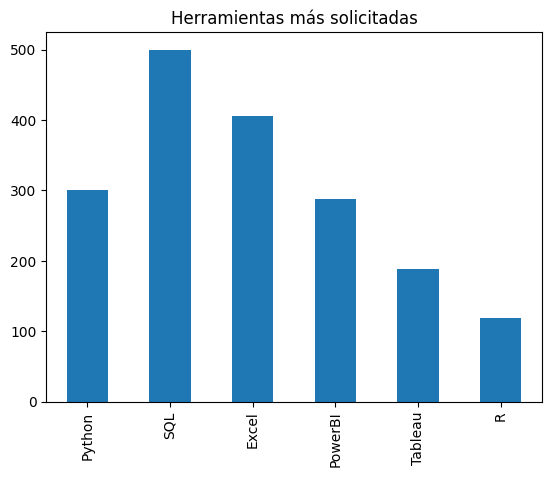

In [16]:
#Herramientas más solicitadas
df[tools].apply(lambda x: (x=="Sí").sum()).plot(kind="bar")
plt.title("Herramientas más solicitadas")
plt.show()

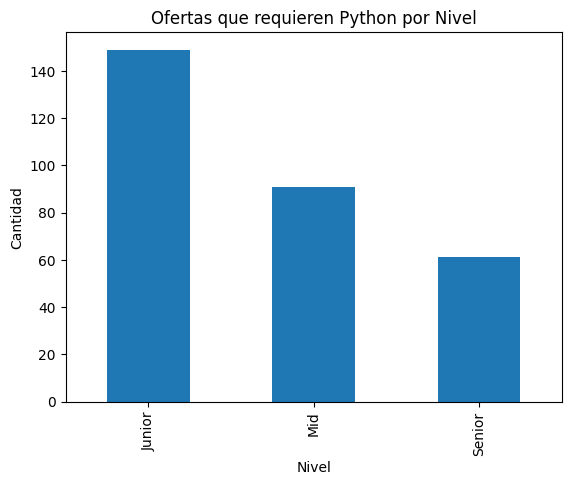

In [ ]:
#Oferta que requieren Python por Nivel
table["Sí"].plot(kind="bar")

plt.title("Ofertas que requieren Python por Nivel")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")

plt.show()

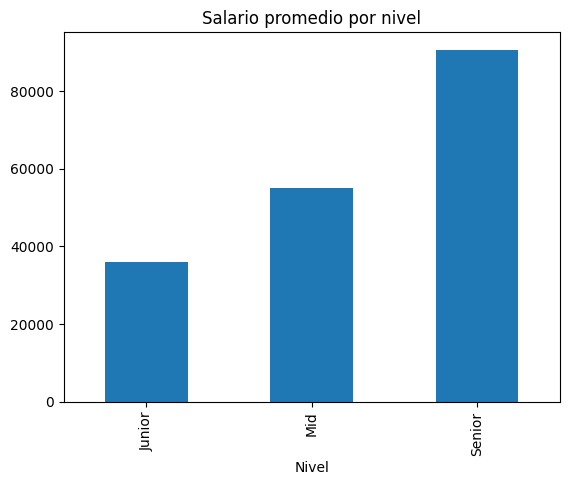

In [18]:
#Salario promedio
df.groupby("Nivel")["Salario"].mean().plot(kind="bar")
plt.title("Salario promedio por nivel")
plt.show()

## Conclusiones

El análisis evidencia que SQL es la herramienta más demandada, consolidándose como una habilidad esencial en el mercado laboral. Excel continúa siendo ampliamente utilizado, reflejando su importancia en procesos de análisis y reporte. Además, Python es más requerido en posiciones Junior dentro del dataset, aunque sigue presente en niveles Mid y Senior, lo que sugiere su relevancia para el crecimiento profesional. Finalmente, se observa una relación positiva entre experiencia y salario, indicando que el desarrollo de habilidades técnicas impacta directamente en la compensación.